## Key Findings from Literature Review
- The Smoking Impact (The Strongest Predictor): Research demonstrates that smoker status has the most profound impact on medical insurance charges. On average, the medical costs for smokers are approximately 3 to 4 times higher than those for non-smokers.
                                                                                                             
- BMI and Smoking Interaction Effect: A high BMI ($\ge 30$, indicating obesity) alone does not drastically trigger extreme 
charges. However, the interaction of High BMI + Smoker status causes insurance charges to rise exponentially, representing the
highest risk pool for insurers.
                 
- Non-linear Relationship with Age: While medical charges generally increase with age as expected, data visualization reveals
that this trend splits into three distinct parallel clusters/lines. These clusters are directly driven by combinations of 
smoking habits and obesity levels rather than a uniform linear increase.
    
- Minor Factors: Demographic features such as sex (gender), number of children, and geographic region show negligible       statistical correlation with total medical charges, making them weak predictors in healthcare financial risk modeling.


### **References & Sources**

1. **Dataset Source & Original Benchmark:** 
   [Kaggle - Medical Cost Personal Datasets by Miri Choi](https://www.kaggle.com/datasets/mirichoi0218/insurance)
   *(This contains the public kernel analyses establishing the 3-4x smoking cost multiplier and the three distinct age clusters).*

2. **Primary Literature Text:** 
   Brett Lantz (2019), *Machine Learning with R*, Packt Publishing. 
   [Packt Publishing - Machine Learning with R (3rd Edition)](https://www.packtpub.com/en-us/product/machine-learning-with-r-9781789343700)
   *(The textbook from which this simulated data originated, detailing the interaction effects of BMI and Smoking).*

3. **Academic Regression & EDA Context:** 
   [An Introduction to Statistical Learning (ISLR)](https://www.statlearning.com/)
   *(The foundational gold-standard reference for understanding how insurance cost datasets behave under multiple linear regression and interaction models).*

## Project Objective
The primary objective of this project is to conduct an Exploratory Data Analysis (EDA) on the Medical Cost Personal Dataset to
understand the underlying factors that determine health insurance premiums (charges). We aim to identify key patterns, trends,
and statistical relationships that drive healthcare costs up or down for an individual.

As a Data Scientist, the goal is to provide actionable insights to the insurance company by identifying high-risk and high-cost
customer segments. This analysis will enable the business to optimize their pricing strategies and implement risk-adjusted 
premium rates based on customer demographics and health habits.

In [20]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#To keep the plots looking clean and professional.
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
df= pd.read_csv("insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.tail(20)

,age,sex,bmi,children,smoker,region,charges
1318,35,male,39.710,4,no,northeast,19496.71917
1319,39,female,26.315,2,no,northwest,7201.70085
1320,31,male,31.065,3,no,northwest,5425.02335
1321,62,male,26.695,0,yes,northeast,28101.33305
1322,62,male,38.830,0,no,southeast,12981.34570
1323,42,female,40.370,2,yes,southeast,43896.37630
1324,31,male,25.935,1,no,northwest,4239.89265
1325,61,male,33.535,0,no,northeast,13143.33665
1326,42,female,32.870,0,no,northeast,7050.02130
1327,51,male,30.030,1,no,southeast,9377.90470


In [8]:
df.shape

(1338, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [14]:
"\n--- Missing Values Percentage ---"
df.isnull().sum() / len(df)* 100

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [16]:
duplicate_count = df.duplicated().sum()
print(print(f"Total duplicate rows found: {duplicate_count}"))

# Agar duplicates hain, toh unka ek glimpse dekhna:
if duplicate_count > 0:
    print("\n--- Duplicate Rows Glimpse ---")
    print(df[df.duplicated(keep=False)].head())

Total duplicate rows found: 1
None

--- Duplicate Rows Glimpse ---
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [19]:
## Fixing the duplicate row
# 1. drop the duplicate row and reset the index 
df_clean = df.drop_duplicates().reset_index(drop=True)

# 2. Check that duplicate row remove or not
print("New Data Shape:", df_clean.shape)
print("Remaining Duplicates:", df_clean.duplicated().sum())

New Data Shape: (1337, 7)
Remaining Duplicates: 0


In [17]:
print("--- Unique values in 'sex': ---", df['sex'].unique())
print("--- Unique values in 'smoker': ---", df['smoker'].unique())
print("--- Unique values in 'region': ---", df['region'].unique())
print("--- Unique values in 'children': ---", df['children'].unique())

--- Unique values in 'sex': --- ['female' 'male']
--- Unique values in 'smoker': --- ['yes' 'no']
--- Unique values in 'region': --- ['southwest' 'southeast' 'northwest' 'northeast']
--- Unique values in 'children': --- [0 1 3 2 5 4]


In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## CHARGES DISTRIBUTION

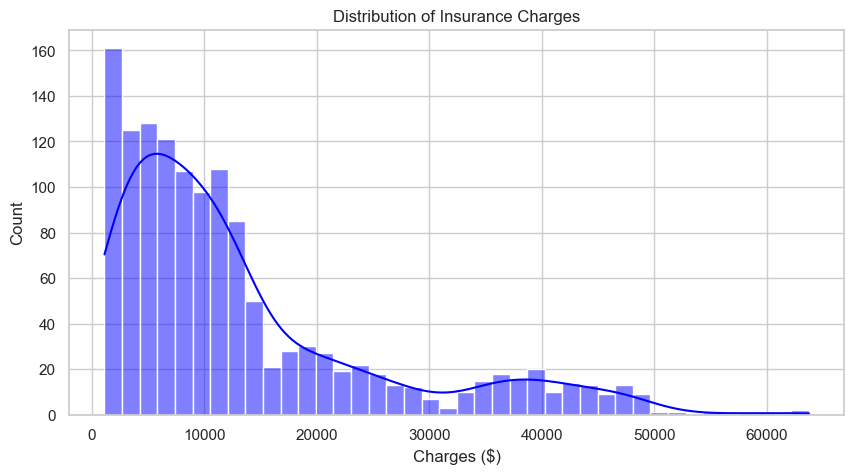

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['charges'], kde=True, color='blue', bins=40)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.show()

- Maximum people are paying low insurance charges between $2,000 and $12,000.
- The graph has a long tail on the right side, which means it is Right-Skewed.
- There is a small, separate hill near $40,000, showing a small group of people with very high bills.

## AGE AND BMI  DISTRIBUTION

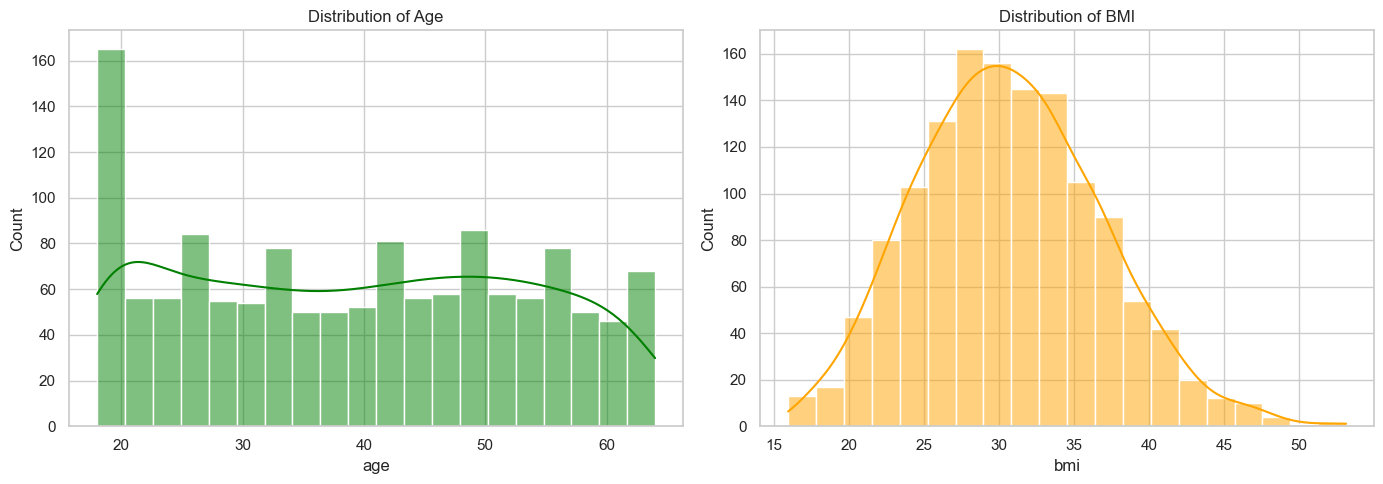

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df_clean['age'], kde=True, color='green', bins=20, ax=axes[0])
# Strict Terminology Note: 'axes[0]' specifies the first plot container in the grid layout
axes[0].set_title('Distribution of Age')

# BMI Distribution
sns.histplot(df_clean['bmi'], kde=True, color='orange', bins=20, ax=axes[1])
# Strict Terminology Note: 'axes[1]' specifies the second plot container in the grid layout
axes[1].set_title('Distribution of BMI')

plt.tight_layout()
plt.show()

- Age Plot: There is a huge spike of young people around 18 to 20 years old taking insurance. After age 20, the number of people
 in every age group is almost equal and flat.

- BMI Plot: The data forms a perfect bell-shaped curve, which means BMI is Normally Distributed. Most people have a BMI right in the middle, around 30.

## COUNT OF ALL CATEGORICAL COLUMNS

C:\Users\tejal\AppData\Local\Temp\ipykernel_323036\1169745223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='sex', palette='Set2', ax=axes[0, 0])
C:\Users\tejal\AppData\Local\Temp\ipykernel_323036\1169745223.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='smoker', palette='Set1', ax=axes[0, 1])
C:\Users\tejal\AppData\Local\Temp\ipykernel_323036\1169745223.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='region', palette='Pastel1', ax=axes[1, 0])
C:\Users\tejal\AppData\L

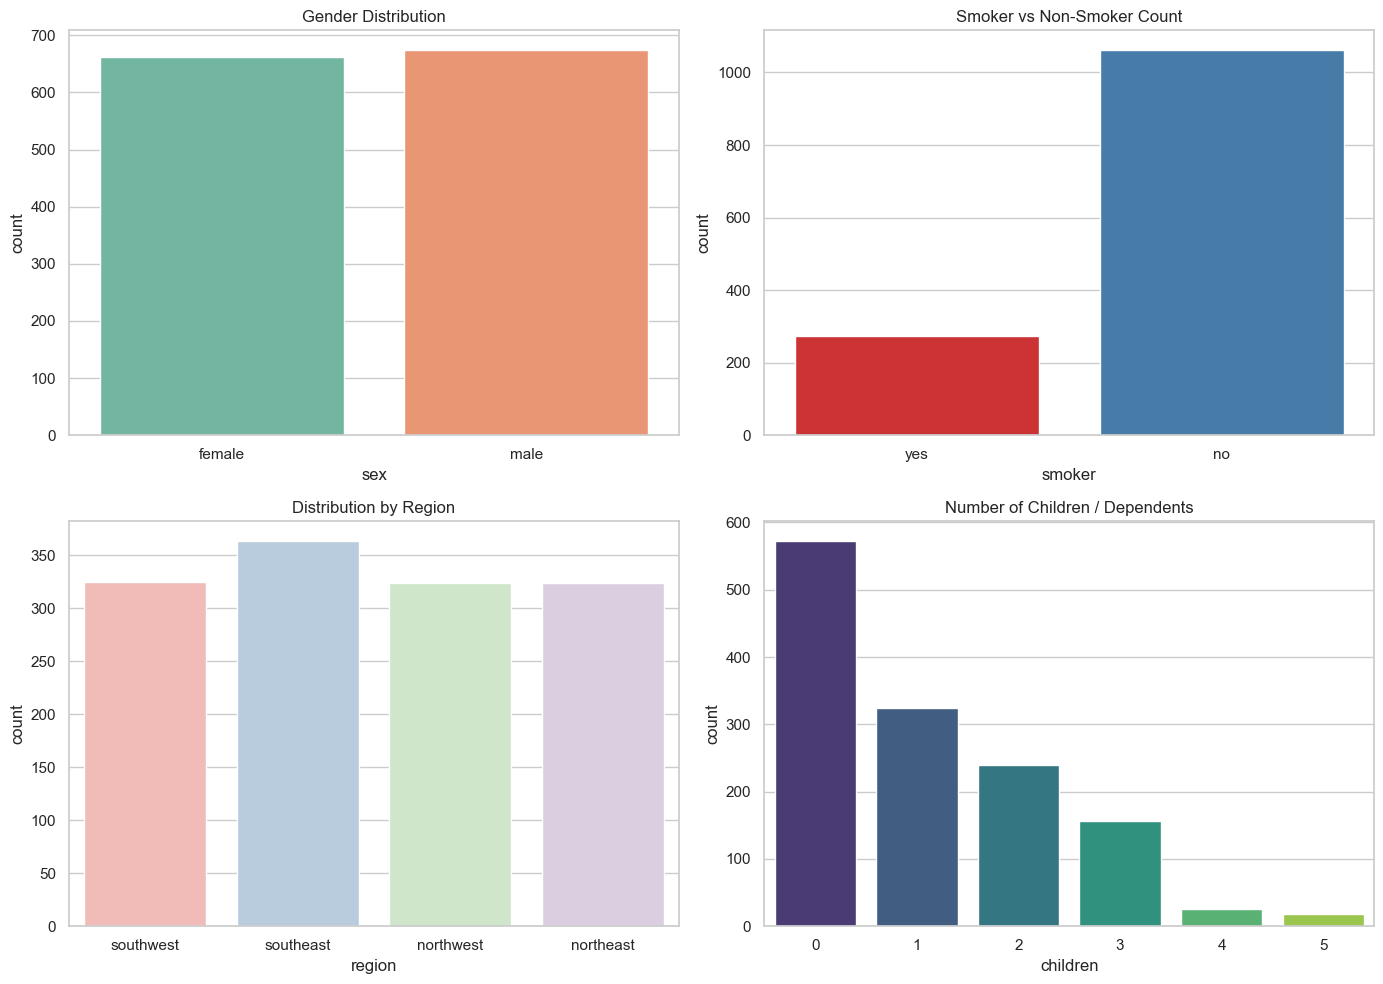

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sex Count
sns.countplot(data=df_clean, x='sex', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Gender Distribution')

# Smoker Count
sns.countplot(data=df_clean, x='smoker', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Smoker vs Non-Smoker Count')

# Region Count
sns.countplot(data=df_clean, x='region', palette='Pastel1', ax=axes[1, 0])
axes[1, 0].set_title('Distribution by Region')

# Children Count
sns.countplot(data=df_clean, x='children', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Number of Children / Dependents')

plt.tight_layout()
plt.show()

- Gender Plot: The number of females and males in this dataset is almost 50-50 (perfectly balanced).
- Smoker Plot: Non-smokers (No) are in a huge majority. Only a very small percentage of people in this data are smokers (Yes).
- Region Plot: The data is evenly distributed across all four parts of the US, with the Southeast region having a tiny bit more people than the others.
- Children Plot: More than half of the people have 0 children. As the number of children increases from 1 to 5, the number of 
  families drops down heavily.

## Charges Distribution by Children

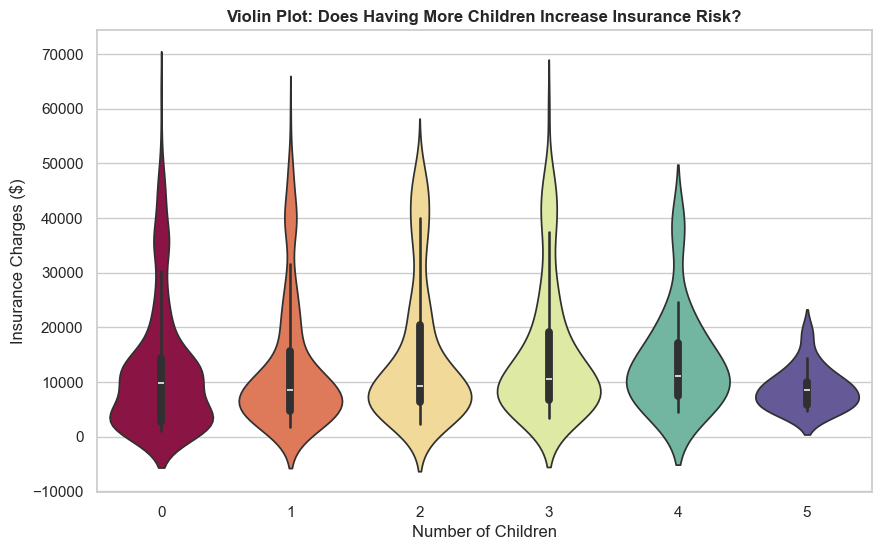

In [35]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='children', y='charges', hue='children', palette='Spectral', legend=False)
plt.title('Violin Plot: Does Having More Children Increase Insurance Risk?', fontsize=12, fontweight='bold')
plt.xlabel('Number of Children')
plt.ylabel('Insurance Charges ($)')
plt.show()

In [ ]:
INSIGHTS:
Density Analysis (0 to 3 Children): Families with 0 to 3 children show high density (wider shapes) at the bottom around $10,000
but they feature very long, sharp vertical tails stretching up to $50,000. This implies the presence of heavy smokers within
these smaller family structures.

The Large Family Cap (4 & 5 Children ): There is a dramatic behavioral shift as we look at families with 4 and 5 children. The 
upper tails completely disappear, and for 5 children, the maximum charges freeze below $25,000.

Actuarial Takeaway: Counter-intuitively, having more dependents does not increase high-cost medical risk. Large families 
(4-5 children) are financially safer for the insurance pool, likely because parents with multiple dependents tend to avoid 
risky health behaviors like smoking, keeping their claims uniformly low.

## Smoker vs Charges

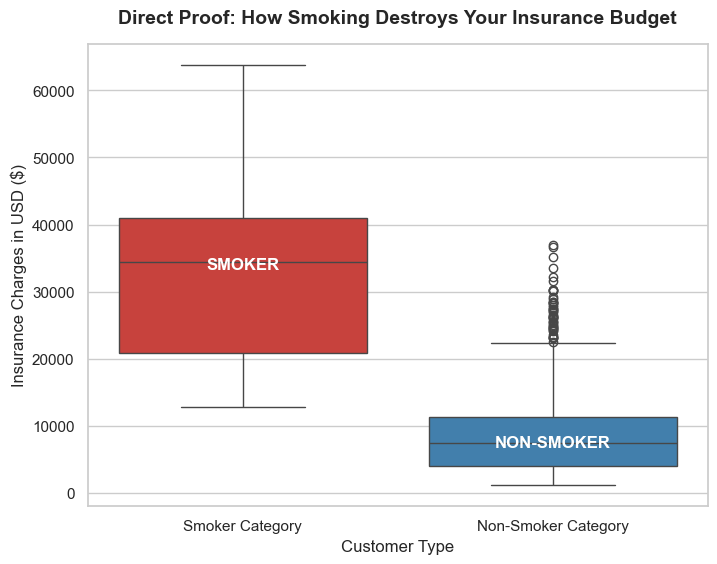

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

my_colors = {'yes': '#de2d26', 'no': '#3182bd'}

ax = sns.boxplot(data=df_clean, x='smoker', y='charges', hue='smoker', palette=my_colors, legend=False)
ax.text(0, 34000, 'SMOKER', color='white', weight='bold', ha='center', va='center', fontsize=12)
ax.text(1, 7500, 'NON-SMOKER', color='white', weight='bold', ha='center', va='center', fontsize=12)
plt.title('Direct Proof: How Smoking Destroys Your Insurance Budget', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Insurance Charges in USD ($)', fontsize=12)
plt.xticks([0, 1], ['Smoker Category', 'Non-Smoker Category'])

plt.show()

INSIGHT:
- The Massive Price Gap: Smoking is the #1 driver of medical costs. Smokers incur a median charge of around $34,000, whereas
non-smokers stay well below $10,000.
- The "Smoking Tax": Choosing to smoke acts like an automatic financial penalty, instantly adding $15,000 to $20,000 to a
  customer's bill regardless of their age or gender.
- The Business Profit Engine: Even though non-smokers pay lower premiums, their low and predictable claims (median $7,300) make
  them the most consistent and stable profit source for the insurance company. Smokers bring in higher revenue but represent 
  high-risk, unpredictable losses.

## Age vs Charges

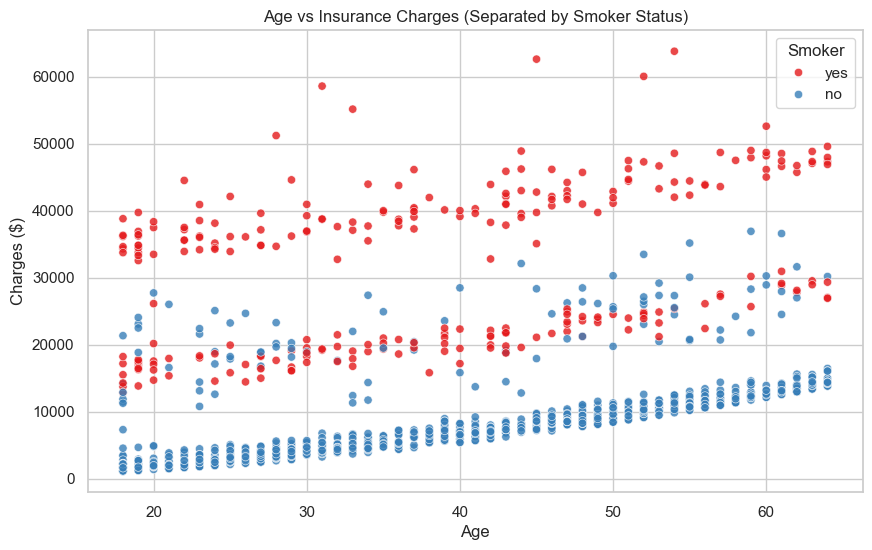

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Age vs Insurance Charges (Separated by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.show()

In [ ]:
The Steady Climb: As age increases, medical charges slowly and steadily climb upward for everyone. This represents the natural
                , expected risk of aging.
The Three Segments: The data beautifully splits into three parallel bands, proving that your final bill isn’t just about age—it
                    depends on your risk bracket:
                                                                                    
Bottom Band: Healthy non-smokers (lowest bills).
Middle Band: Fit smokers (BMI < 30) mixed with high-risk non-smokers.
Top Band: Obese smokers (BMI > 30) facing maximum costs.
                                                                                    
Habit Beats Youth: A 19-year-old smoker sits in the top band paying around $35,000, while a 64-year-old non-smoker sits in the
bottom band paying under $15,000. This proves that bad health habits instantly destroy any financial advantage of being young.

## BMI vs Charges

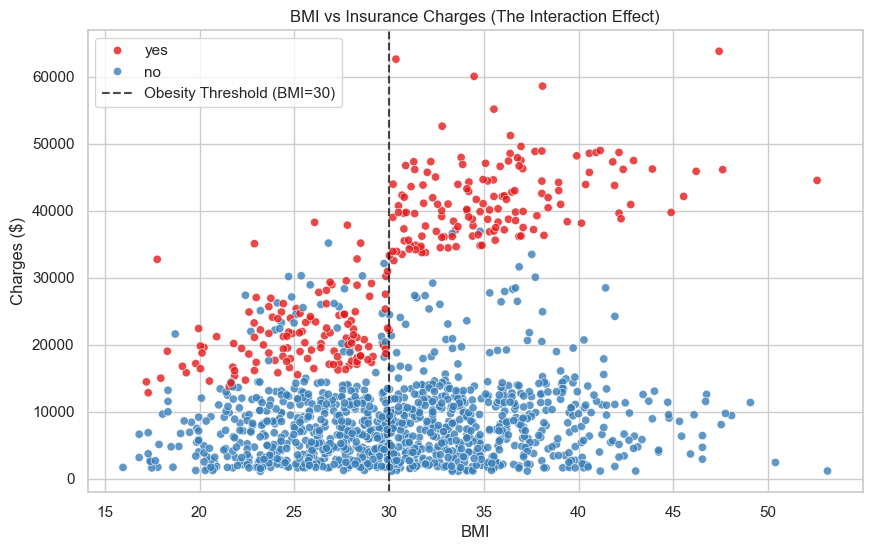

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
# Strict Terminology Note: 'plt.axvline' draws a vertical line at BMI=30 to mark the clinical obesity threshold
plt.axvline(x=30, color='black', linestyle='--', alpha=0.7, label='Obesity Threshold (BMI=30)')
plt.title('BMI vs Insurance Charges (The Interaction Effect)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend()
plt.show()

- The Safe Zone: For non-smokers (blue dots), crossing the BMI 30 line (Obesity) does not increase their bills significantly.
Their charges remain low and stable.

- The Danger Zone: For smokers (red dots), crossing BMI 30 acts like a catastrophic switch. Below 30, they pay around $20,000,
but above 30, their bills explode instantly to over $40,000.

- The Lethal Multiplier: Being obese alone is fine, and smoking alone is bad—but combining Obesity + Smoking creates a lethal
combination that instantly doubles the financial risk for the company.

## All Columns vs Insurance Charges (Heatmap)

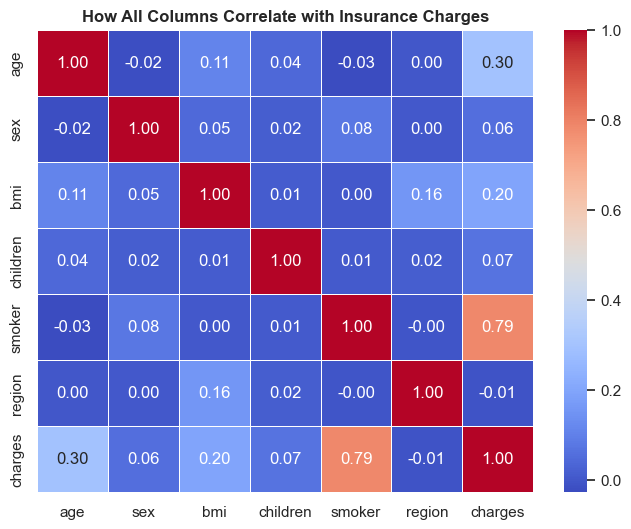

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df_heatmap = df_clean.copy()

df_heatmap['sex'] = df_heatmap['sex'].astype('category').cat.codes
df_heatmap['smoker'] = df_heatmap['smoker'].astype('category').cat.codes
df_heatmap['region'] = df_heatmap['region'].astype('category').cat.codes

corr_matrix = df_heatmap.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('How All Columns Correlate with Insurance Charges', fontsize=12, fontweight='bold')
plt.show()

INSIGHTS:
- Smoker Column (Score = 0.79): This is the highest score on the chart. It provides absolute mathematical proof that smoking 
  status is the single most powerful factor driving insurance costs higher.
    
- Age Column (Score = 0.30): Shows a moderate positive correlation. As a customer gets older, their medical risk and insurance
 charges naturally increase over time.

- BMI Column (Score = 0.20): Shows a weak-to-moderate positive baseline correlation. On its own, a higher body mass index 
 slightly raises costs, though its extreme impact only unlocks when combined with smoking.

- Sex, Children, & Region (Scores $\le$ 0.07): These scores are virtually flat and near zero. This mathematically proves that a customer's gender, number of kids, or geographic region have almost zero direct influence on their basic insurance
billing tier.

## SUMMARY

In [ ]:
1. Cleaned Missing & Duplicate Values
Why: To make sure wrong or incomplete data did not mess up our final results.

2. Checked Each Column Separately (Univariate Analysis)
Why: To understand the background of our customers, like their age groups, weight (BMI), and general habits.

3. Created a Box Plot (Smoker vs Charges)
Why: To see the exact financial gap between the medical bills of smokers and non-smokers.

4. Created a Scatter Plot (Age vs Charges)
Why: To check if getting older automatically makes insurance more expensive.

5. Created a Scatter Plot (BMI vs Charges)
Why: To find out if being overweight increases your bill, and how smoking makes it worse.

6. Created a Violin Plot (Children vs Charges)
Why: To see if having more kids or a larger family increases the financial risk for the insurance company.

7. Created a Correlation Heatmap (All Columns vs Charges)
Why: To get mathematical proof (numbers from 0 to 1) showing which column is the absolute king in changing insurance costs.